### 第22章 人脸识别
#### 22.1 级联分类器
1. 基本原理：在开始阶段仅进行非常简单的判断，排除明显不符合要求的实例。被排除的负类不再参与后续分类，提高后面分类的速度
2. Harr 级联分类器：Haar 特征将像素矩形区域划分为白黑两部分，计算该区域的平均灰度差值作为特征。


- 函数 `objects = cv2.CascadeClassifier.detectMultiScale(image[, scaleFactor[, minNeighbors[, flags[, minSize[, maxSize]]]]])` 用来检测人脸
    - `image` 待检测的图像，通常为灰度图
    - `scaleFactor` 表示在前后两次相继的扫描中，搜索窗口的缩放比例，默认为1.1


    - `retval` 距离值，也称密度值或紧密度，返回每个点到相应中心点距离的平方和
    - `bestLabels` 各个数据点的最终分类标签（索引）
    - `centers` 每个分类的中心点坐标
    - `data` 待处理的数据集合，是 `np.float32` 类型，每个特征放在单独一列
    - `K` 聚类中心的数量
    - `bestLabels` 用来保存每个数据点的最终分类标签，实际调用时设置为 `None`
    - `criteria` 迭代终止条件，是一个包含三个元素的元组：`(type, max_iter, epsilon)`
        - `type` 指定迭代终止的条件，可以是 
            - `cv2.TERM_CRITERIA_EPS` 迭代过程中两次结果之间的最大变化量小于 `epsilon` 时停止迭代
            - `cv2.TERM_CRITERIA_MAX_ITER` 迭代次数超过 `max_iter` 时停止迭代 
            - `cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX` 上述两个条件中任意一个满足时停止迭代
        - `max_iter` 最大迭代次数
        - `epsilon` 迭代过程中两次结果之间的最大变化量（精度阈值）
    - `attempts` 指定该值，可以让算法使用不同的初始值进行多次（attempts）次迭代，以选择最佳结果
    - `flags` 指定算法的实现方式，可选值有
        - `cv2.KMEANS_RANDOM_CENTERS` 随机选择初始中心点
        - `cv2.KMEANS_PP_CENTERS` 选择初始中心点的方式是使用 K 均值++ 方法
        - `cv2.KMEANS_USE_INITIAL_LABELS` 使用用户提供的初始标签；如果attempts值大于1，后续尝试使用随机值或者半随机值作为第一次分类中心点

发现5个人脸!
其位置分别是：
[[290  14  74  74]
 [ 35  77  62  62]
 [127  58  65  65]
 [565  64  64  64]
 [443  62  71  71]]


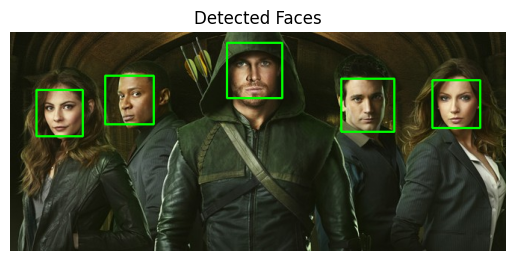

In [ ]:
import cv2
import matplotlib.pyplot as plt

# =============== 1 原始图像处理 ====================
image = cv2.imread("image/dface3.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# ================ 2 加载分类器 ========================
faceCascade = cv2.CascadeClassifier("data/haarcascades/haarcascade_frontalface_default.xml")
# ================= 3 人脸检测========================
faces = faceCascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(5, 5))
# =============== 4 打印输出=====================
print("发现{0}个人脸!".format(len(faces)))
print("其位置分别是：")
print(faces)
# ==================5 标注人脸及显示=======================
for x, y, w, h in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.title("Detected Faces")
plt.show()